In [125]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

In [126]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.datasets import make_regression

In [127]:
X,y=make_regression(n_samples=100,n_features=2,noise=0,n_targets=1)

In [128]:
df=pd.DataFrame({"feature1":X[:,0],"feature2":X[:,1],"output":y})
df.head()

,feature1,feature2,output
0,-1.799584,0.902710,74.809885
1,-0.627565,2.006780,188.216368
2,-0.032539,-0.502605,-48.371769
3,0.128341,0.151583,15.358514
4,-1.017722,0.332769,25.275827


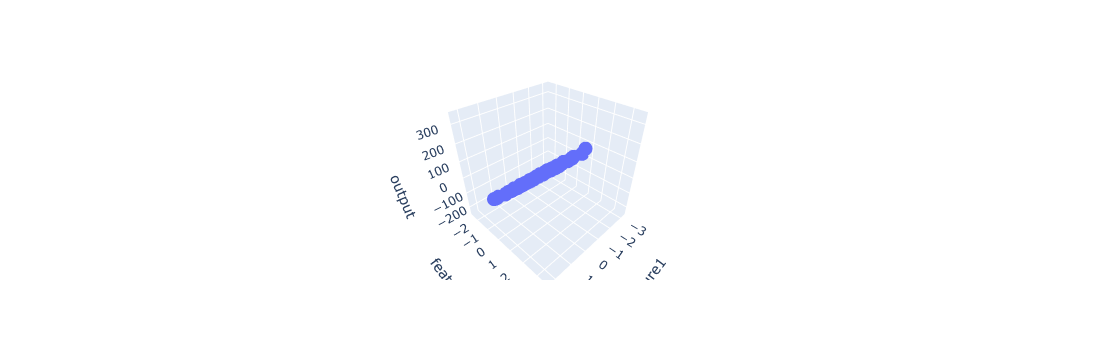

In [129]:
fig=px.scatter_3d(df,x=df.iloc[:,0],y=df.iloc[:,1],z=df.iloc[:,2])
fig.show()

In [130]:
x=df.iloc[:,0:2]
y=df.iloc[:,2]

In [131]:
from sklearn.model_selection import train_test_split

In [132]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.2)

In [133]:
x_train.shape[0]

80

In [134]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [135]:
y_pred=lr.predict(x_test)

In [136]:
print("MAE",mean_absolute_error(y_pred,y_test))
print("MSE",mean_squared_error(y_pred,y_test))
print("r2_score",r2_score(y_pred,y_test))

MAE 1.5232259897857146e-14
MSE 3.2126360365125706e-28
r2_score 1.0


In [137]:
lr.coef_

array([ 6.49546104, 95.82152704])

In [138]:
lr.intercept_

np.float64(1.6653345369377348e-16)

# multiple regression with the help of Linearregression()

In [139]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [140]:
from sklearn.datasets import load_diabetes
X,y=load_diabetes(return_X_y=True)

In [141]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=0,test_size=0.2)

In [142]:
x_train.shape

(353, 10)

In [143]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [144]:
y_pred=lr.predict(x_test)

In [145]:
from sklearn.metrics import r2_score
print("var",r2_score(y_test,y_pred))

var 0.3322332173106183


# Making our own multiple linear regression class

In [171]:
class meralr:
    def __init__(self):
        self.coeff=None
        self.intercept=None
    def fit(self,x_train,y_train):
        x_train=np.insert(x_train,0,1,axis=1)
        beta=(np.linalg.inv(np.dot(x_train.T,x_train))).dot(x_train.T).dot(y_train)
        self.intercept=beta[0]
        self.coeff=beta[1:]
        print(self.coeff.shape)
    def predict(self,x_test):
        print(x_test.shape)
        y_pred=self.intercept+np.dot(x_test,self.coeff)
        print(y_pred)
    

In [172]:
lr=meralr()
lr.fit(x_train,y_train)

(10,)


In [173]:
lr.predict(x_test[0])

(10,)
238.46949509209486


In [174]:
lr.predict(x_test)

(89, 10)
[238.46949509 248.92812015 164.05732579 120.30774826 187.42483427
 259.04746969 113.55788482 188.07762807 149.49521726 236.00758247
 172.24561893 178.87936198 109.16034679  92.13333574 243.32766187
  87.35445583 155.72165684  66.98992013 100.42233598 218.0957236
 196.6646301  161.2972646  161.70870434 156.52404017 197.88770177
 167.58280539 120.7427979   84.84033238 192.03438449 160.60496231
 175.17348034  84.22759674 145.80002729 145.97264454 140.96436257
 197.00423168 165.94319214 190.6597389  128.22361933 206.41497077
  84.3575017  164.02262498 144.10639773 184.68996616 177.80076449
  74.33261184 143.36644877 138.68063137 120.80857573 234.34288711
 161.94132344  74.54325994 154.71683591 156.78815442 237.41798756
 174.23210042 190.87871793 118.98140389 132.20521501 168.52914416
 214.73950634 171.42284128 157.37648738 108.86915142 257.06294458
 152.17962851  82.43753531 231.56764949 202.9088885   47.18175623
  78.46774353 129.30214156 104.60094227 144.65245785 132.27795739
 1

In [165]:
from sklearn.metrics import r2_score
print("var",r2_score(y_test,y_pred))

var 0.3322332173106183
